In [60]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
from stress_risk.utils.data import add_cond2df
import pandas as pd
import pingouin

# put behav (probit - rnp), neural (decode - across r/sd), stress-level (AUC-cortisol, self rated) in context

# shifts in prior and decoding params in 'shifts_decode-priors.ipynb'

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [58]:
# behav - probit
df_probit = pd.read_csv('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates/bambi-1_subseswise_params.csv')

# neural - decoding
df_decod_acc = pd.read_csv('~/data/ds-stressrisk/derivatives/decoding_accuracy_allSub_allSes.csv').rename(mapper={'r':'r_decod'},axis=1)
df_decod_sd = pd.read_csv('~/data/ds-stressrisk/derivatives/decoding_sd_allSub_allSes.csv')
df_decod = df_decod_acc.set_index(['subject','session']).join(df_decod_sd.set_index(['subject','session']))

# combine (session as index)
df_subses = df_probit.set_index(['subject','session']).join(df_decod)
df_subses = add_cond2df(df_subses)

# behav - NLC
df_ch_risky_prior = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_risky_prior_model-1.csv').set_index('subject') # subwise
df_n1_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n1_evidence_sd.csv').set_index(['subject','session']) #subseswise


# stress level from ses2
from utils import get_stress_level
df_auc = get_stress_level()
df_auc_sr = pd.read_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress.csv').set_index('subject') #self rated


# motion as confound?
df_motion = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_motion.csv').set_index(['subject', 'session'])

# combine everything, generating difference measure from ses2-ses2
df_subs = pd.DataFrame(df_subses.unstack('session')[('rnp',2)] - df_subses.unstack('session')[('rnp',1)], columns=['rnp_diff'])
df_subs = df_subs.join(df_auc).join(df_auc_sr).set_index('group',append=True)
df_subs = df_subs.join(df_ch_risky_prior)


Text(0.5, 1.0, 'corr: r = 0.027, p = 0.792')

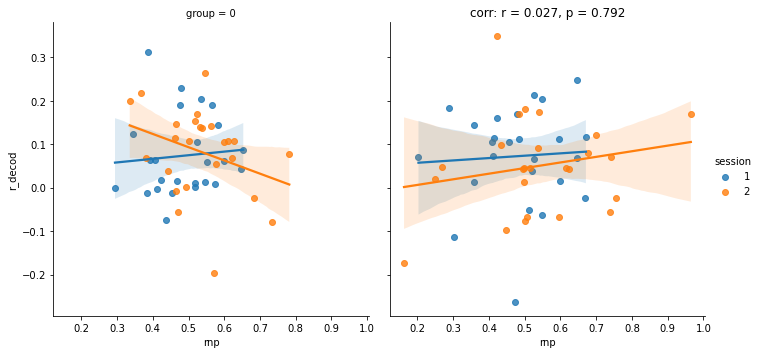

In [19]:
# correlate variables df_subses (group, session seperately)

from scipy import stats
df = df_subses
y = 'r_decod'
x = 'rnp'
c = np.round(stats.pearsonr(df[x],df[y]), 3)

sns.lmplot(x=x, y=y, data = df.reset_index(), hue='session', col='group')
plt.title(f'corr: r = {c[0]}, p = {c[1]}')


Text(0.5, 1.0, 'corr: r = -0.115, p = 0.431')

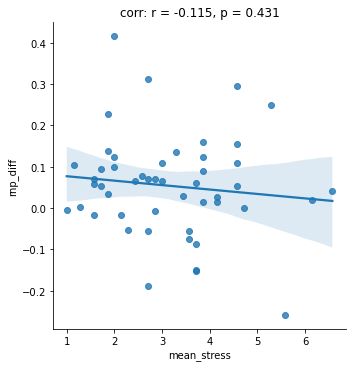

In [51]:
# correlate variables df_subs

from scipy import stats
df = df_subs.dropna()
y = 'rnp_diff'
x = 'mean_stress'#'AUC'
c = np.round(stats.pearsonr(df[x],df[y]), 3)

sns.lmplot(x=x, y=y, data = df.reset_index())
plt.title(f'corr: r = {c[0]}, p = {c[1]}')

In [72]:
df_decod.groupby(['session', 'group']).apply(lambda d: pingouin.ttest(d['sd'], 0.0))

T  dof alternative         p-val       CI95%  \
session group                                                                
1       0     T-test  20.279197   24   two-sided  1.307309e-16  [0.0, 0.0]   
        1     T-test  19.810416   24   two-sided  2.222968e-16  [0.0, 0.0]   
2       0     T-test  18.692618   24   two-sided  8.257426e-16  [0.0, 0.0]   
        1     T-test  16.984304   24   two-sided  7.049823e-15  [0.0, 0.0]   

                       cohen-d       BF10  power  
session group                                     
1       0     T-test  4.055839  3.757e+13    1.0  
        1     T-test  3.962083  2.264e+13    1.0  
2       0     T-test  3.738524  6.483e+12    1.0  
        1     T-test  3.396861  8.411e+11    1.0

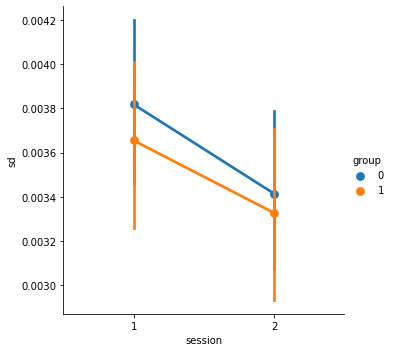

In [76]:
# catplot 
sns.catplot(data=df_decod.reset_index(), x='session', y='sd', hue='group', kind='point', errorbar='se')

Text(23.830625000000012, 0.5, 'risky_prior_mu diff (ses2-ses1)')

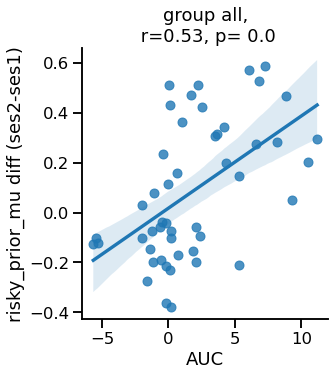

In [61]:
sns.set_context('talk')

group ='all' # 0, 1
temp = df_subs#.xs(group,0,'group')
sns.lmplot(x='AUC',y='risky_prior_mu', data=temp)
cor = pingouin.corr(temp['AUC'],temp['risky_prior_mu'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 2)
plt.title(f'group {group},\n r={r_}, p= {p}')
plt.ylabel('risky_prior_mu diff (ses2-ses1)')